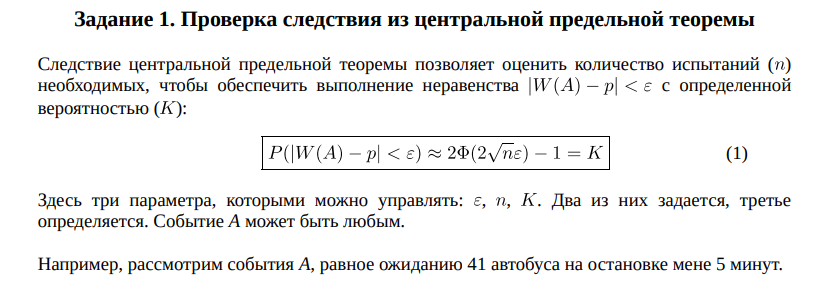

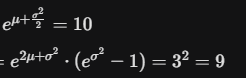

**Create lognormal distr object with calculated params (theta, sigma, mu, m)**

In [2]:
from scipy import stats
from math import sqrt, log, exp
import pandas as pd


theta_threshold = 0

T_mean = 10
T_std = 3

sigma = sqrt(
    log(1 + (T_std * T_std) / (T_mean * T_mean)))  # from lognorm variance equation
mu = log(T_mean) - (sigma * sigma) / 2 # from lognorm mean equation 
m = exp(mu)

bus_lognorm = stats.lognorm(s=sigma, loc=theta_threshold, scale=m)

calc_df = pd.DataFrame(
    {
        "Parameter": ["sigma (shape)", "mu (log mean)", "m (scale/median)"],
        "Value": [sigma, mu, m],
        "Description": [
            "Variance of log(T)",
            "Mean of log(T)",
            "Median of T",
        ],
    }
)
display(calc_df)

,Parameter,Value,Description
0,sigma (shape),0.293560,Variance of log(T)
1,mu (log mean),2.259496,Mean of log(T)
2,m (scale/median),9.578263,Median of T


**Lognormal plot**

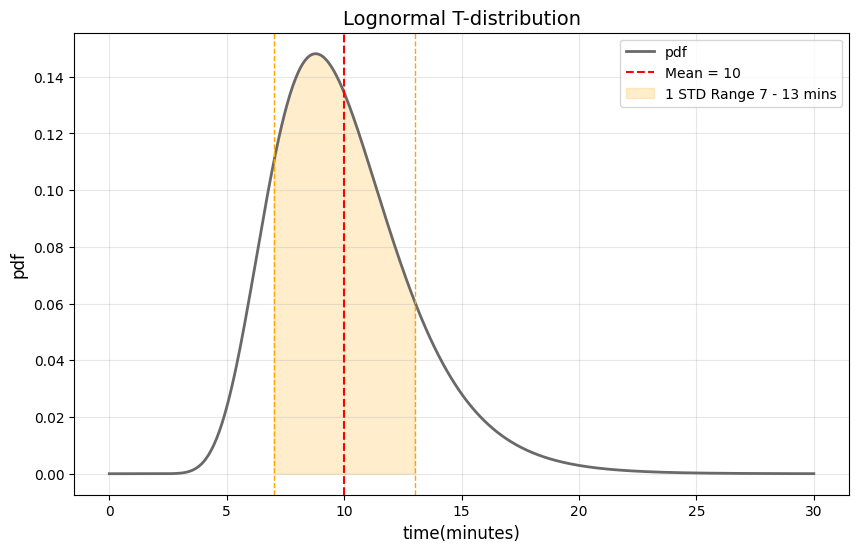

In [3]:
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(0, 30, 500)
pdf = bus_lognorm.pdf(x)

low_std = T_mean - T_std
high_std = T_mean + T_std

plt.figure(figsize=(10, 6))
plt.plot(x, pdf, label="pdf", color="dimgray", lw=2)

plt.axvline(T_mean, color="red", linestyle="--", label=f"Mean = {T_mean}")

# plt.axvline(m, color="green", linestyle=":", label=f"Median (m) = {m:.2f}")

plt.axvline(low_std, color="orange", linestyle="--", lw=1)
plt.axvline(high_std, color="orange", linestyle="--", lw=1)

x_filled = np.linspace(low_std, high_std, 100)
y_filled = bus_lognorm.pdf(x_filled)
plt.fill_between(
    x_filled,
    y_filled,
    color="orange",
    alpha=0.2,
    label=f"1 STD Range {low_std} - {high_std} mins",
)

plt.title("Lognormal T-distribution", fontsize=14)
plt.xlabel("time(minutes)", fontsize=12)
plt.ylabel("pdf", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

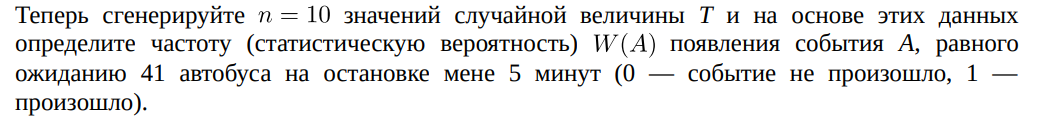

In [4]:
bus_n = 10
arrival_time = 5


def generate_stat_probs(N=1, n=bus_n):
    stat_probs_array = []

    for _ in range(N):
        generated_time_vals = bus_lognorm.rvs(n)
        if N == 1:
            display(generated_time_vals)

        statistical_p = np.sum(generated_time_vals < arrival_time) / len(
            generated_time_vals
        )

        stat_probs_array.append(statistical_p)

    return stat_probs_array


real_p = bus_lognorm.cdf(arrival_time)
display(f"W(A) = {generate_stat_probs()[0]}, real_p = {real_p}")

array([ 9.17020576, 12.80669577,  7.4555815 ,  8.3116196 , 12.61300148,
       11.08805659,  7.23005746,  8.68693668,  7.36405166,  9.40995788])

'W(A) = 0.0, real_p = 0.013400844805209403'

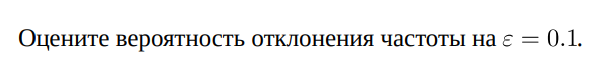

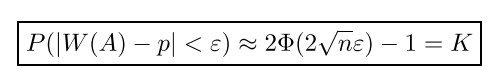

**По интегральной теореме Лапласа**

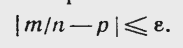
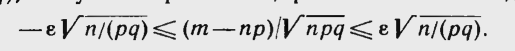

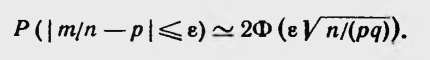, 


In [5]:
success_p = 0.5
fail_q = 1 - 0.5

eps = 0.1

# By CDFs subtraction
arg_for_phi = eps * sqrt(bus_n / (success_p * fail_q))
deviation_p = stats.norm.cdf(arg_for_phi) - stats.norm.cdf(-arg_for_phi)

# Formula
K = 2 * stats.norm.cdf(2 * eps* sqrt(bus_n)) - 1

display(
    f"Cdf subtraction method = {deviation_p}, double symmetric areas formula= {K}",
)

'Cdf subtraction method = 0.4729107431344619, double symmetric areas formula= 0.4729107431344619'

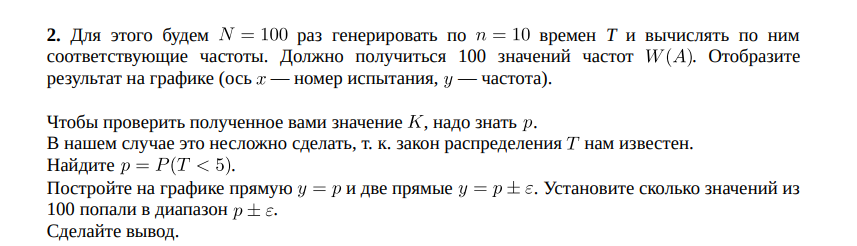

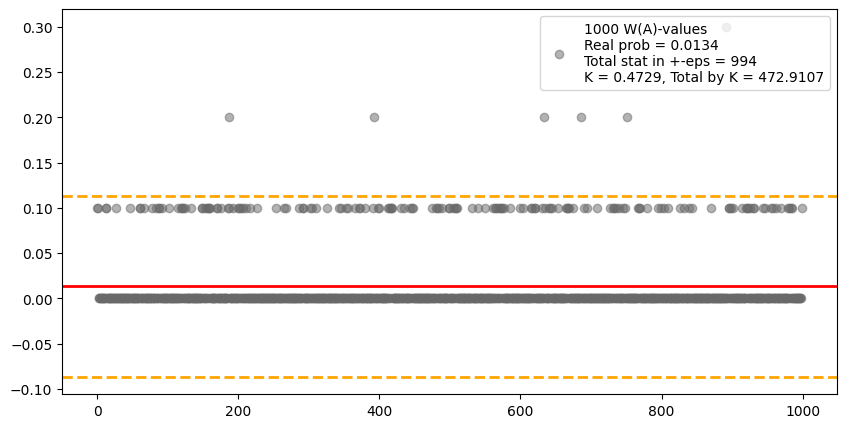

In [6]:
N = 1000
stat_probs = generate_stat_probs(N=N)

left_bound = real_p - eps
right_bound = real_p + eps
mask = (stat_probs > left_bound) & (stat_probs < right_bound)
vals_in_range = np.sum(mask)

iter_nums = np.arange(len(stat_probs))
plt.figure(figsize=(10, 5))
plt.plot(
    iter_nums,
    stat_probs,
    "o",
    color="dimgray",
    alpha=0.5,
    label=f"{N} W(A)-values\nReal prob = {real_p:.4f}\nTotal stat in +-eps = {vals_in_range}\nK = {K:.4f}, Total by K = {N * K:.4f}",
)
plt.axhline(y=real_p, color="red", linewidth=2, linestyle="-")
plt.axhline(y=left_bound, color="orange", linewidth=2, linestyle="--")
plt.axhline(y=right_bound, color="orange", linewidth=2, linestyle="--")

plt.legend(loc="upper right")
plt.show()

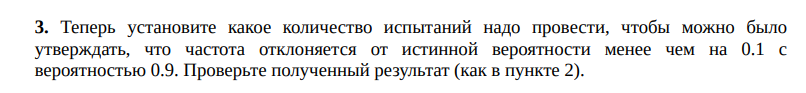

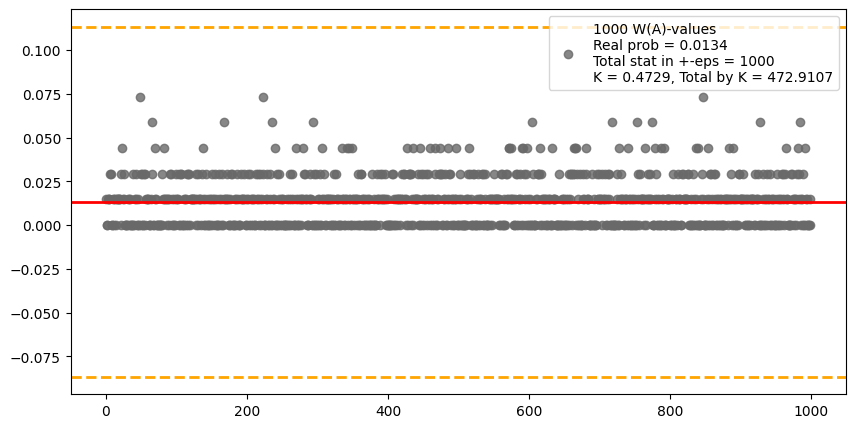

In [7]:
K_for_reverse = 0.9
arg_p_for_quantile = (K_for_reverse + 1) / 2
t_val = stats.norm.ppf(arg_p_for_quantile)

estimation_n = (t_val * t_val) / (4 * eps * eps)

from math import ceil
stat_probs_for_ppf = generate_stat_probs(N=1000, n=ceil(estimation_n))

left_bound = real_p - eps
right_bound = real_p + eps
mask = (stat_probs_for_ppf > left_bound) & (stat_probs_for_ppf < right_bound)
vals_in_range = np.sum(mask)

iter_nums = np.arange(len(stat_probs_for_ppf))
plt.figure(figsize=(10, 5))
plt.plot(
    iter_nums,
    stat_probs_for_ppf,
    "o",
    color="dimgray",
    alpha=0.8,
    label=f"{N} W(A)-values\nReal prob = {real_p:.4f}\nTotal stat in +-eps = {vals_in_range}\nK = {K:.4f}, Total by K = {N * K:.4f}",
)
plt.axhline(y=real_p, color="red", linewidth=2, linestyle="-")
plt.axhline(y=left_bound, color="orange", linewidth=2, linestyle="--")
plt.axhline(y=right_bound, color="orange", linewidth=2, linestyle="--")

plt.legend(loc="upper right")
plt.show()

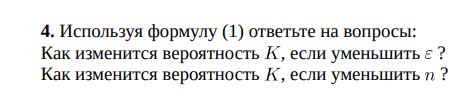

1. Вероятность уменьшится

2. Вероятность уменьшится

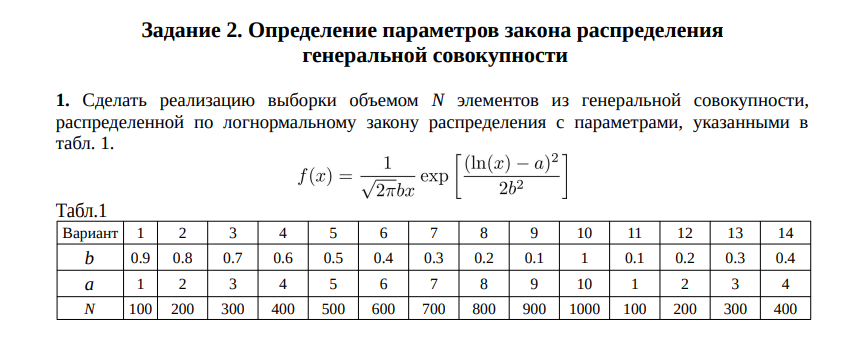

In [8]:
a_mu = 3
b_sigma = 0.7
total_times = 300

population_lognorm = stats.lognorm(s=b_sigma, loc=0, scale=exp(a_mu))
test_sample = np.array(population_lognorm.rvs(size=total_times))
test_sample.sort()

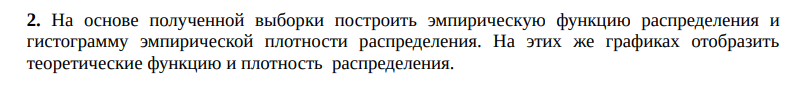

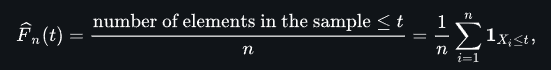


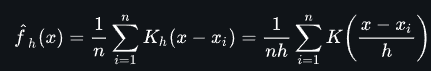

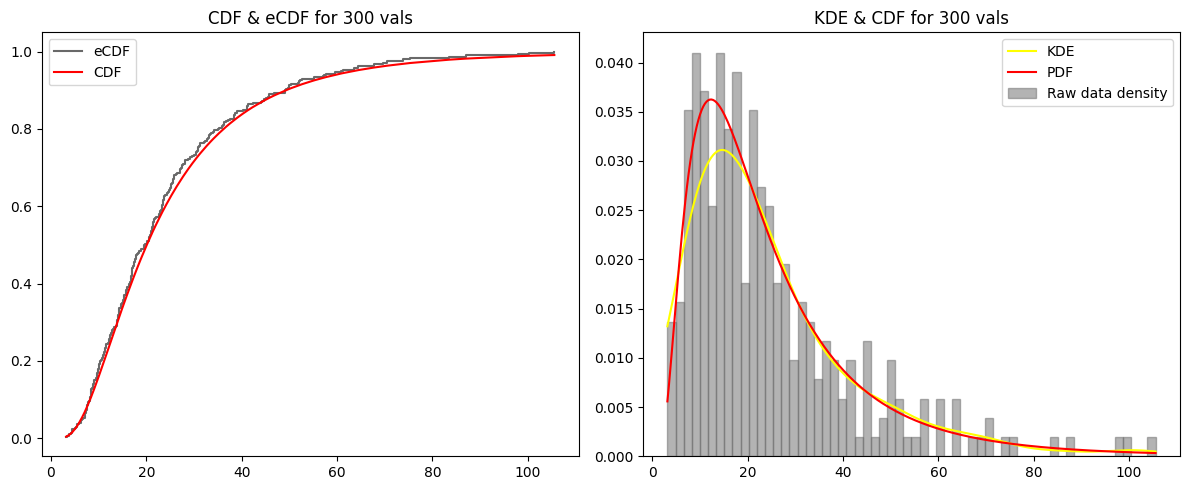

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# eCDF-CDF
axes[0].step(
    test_sample,
    np.arange(1, len(test_sample) + 1) / len(test_sample),
    alpha=1,
    where="post",
    color="dimgrey",
    label=f"eCDF",
)
axes[0].set_title(f"CDF & eCDF for {total_times} vals")
axes[0].plot(
    test_sample,
    population_lognorm.cdf(test_sample),
    alpha=1,
    color="red",
    label=f"CDF",
)
axes[0].legend()

# KDE-PDF
kde = stats.gaussian_kde(test_sample)
x_range = np.linspace(min(test_sample), max(test_sample), 300)
kde_values = kde(x_range)

axes[1].plot(
    x_range,
    kde_values,
    alpha=1,
    color="yellow",
    label=f"KDE",
)

axes[1].plot(
    x_range,  
    population_lognorm.pdf(x_range), 
    color="red",
    label="PDF",
)
axes[1].hist(
    test_sample,
    bins=int(total_times / 5),
    density=True,
    alpha=0.5,
    color="dimgrey",
    edgecolor="dimgrey",
    label="Raw data density",
)
axes[1].set_title(f"KDE & CDF for {total_times} vals")
axes[1].legend()

plt.tight_layout()
plt.show()

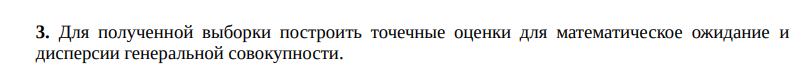

**Sample mean**

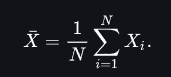

**Unbiased sample variance**

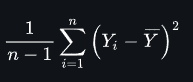

In [12]:
sample_mean = np.sum(np.log(test_sample)) / len(test_sample)

unb_sample_variance = (np.sum(
    (np.log(test_sample) - sample_mean) * (np.log(test_sample) - sample_mean)
) / (len(test_sample) - 1))


display(
    f"Sample mean = {sample_mean}, unbiased sample std = {sqrt(unb_sample_variance)}",
)

'Sample mean = 2.964828207679317, unbiased sample std = 0.6844659980026055'

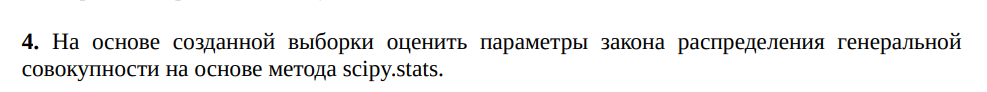

In [13]:
b_fit, _, scale_fit = stats.lognorm.fit(test_sample, floc=0)
a_fit = np.log(scale_fit)

display(
    f"Fitted mu(a) = {a_fit}, fitted sigma(b) = {b_fit}",
)

'Fitted mu(a) = 2.964828207679317, fitted sigma(b) = 0.6833242691043279'

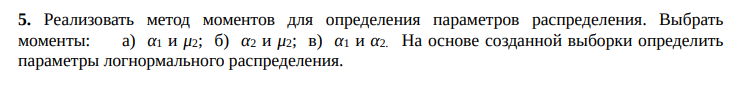

In [68]:
alpha1 = sample_mean
alpha2 = np.mean(test_sample**2)
mu2 = alpha2 - alpha1**2  

# 1. alpha1, mu2 
b_mom_alp1mu2 = np.sqrt(np.log((mu2 / (alpha1 * alpha1)) + 1))
a_mom_alp1mu2 = np.log(alpha1) - (b_mom_alp1mu2**2 / 2)
display(
    f"A) alpha1, mu2: a = {a_mom_alp1mu2}, b = {b_mom_alp1mu2}",
)

# 2. alpha2, mu2 
# alpha1^2 = alpha2 - mu2
b_mom_alp2mu2 = np.sqrt(np.log(alpha2 / (alpha2 - mu2)))
a_alp2mu2 = (np.log(alpha2) - 2 * (b_mom_alp2mu2**2)) / 2
display(
    f"B) alpha2, mu2: a = {a_alp2mu2}, b = {b_mom_alp2mu2}",
)

# 3. alpha1, alpha2
b_mom_alp1alp2 = np.sqrt(np.log(alpha2 / (alpha1 * alpha1)))
a_mom_alp1alp2 = 2 * np.log(alpha1) - 0.5 * np.log(alpha2)
display(
    f"V) alpha1, alpha2: a = {a_mom_alp1alp2}, b = {b_mom_alp1alp2}",
)

'A) alpha1, mu2: a = -1.2616308024398482, b = 2.1676717811643162'

'B) alpha2, mu2: a = -1.2616308024398464, b = 2.167671781164316'

'V) alpha1, alpha2: a = -1.2616308024398482, b = 2.1676717811643162'

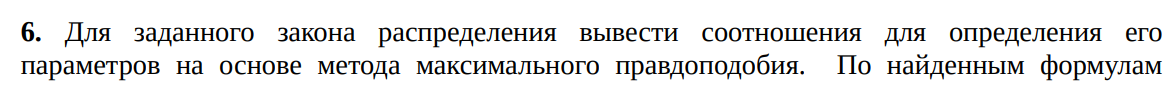
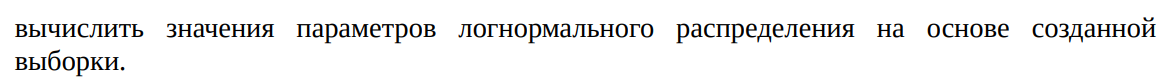

In [69]:
log_data = np.log(test_sample)

a_mle = np.mean(log_data)
b_mle = np.std(log_data)  

display(f"MLE estimated mean (a) = {a_mle}, MLE estimated std (b) = {b_mle}")

'MLE estimated mean (a) = 2.967647860814793, MLE estimated std (b) = 0.7191987617786653'

In [70]:
import pandas as pd
data = {
    "Method": [
        "Theoretical",
        "scipy.stats",
        "Moments (a1, u2)",
        "Moments (a2, u2)",
        "Moments (a1, a2)",
        "Maximum likelihood estimation",
    ],
    "a": [a_mu, a_fit, a_mom_alp1mu2, a_alp2mu2, a_mom_alp1alp2, a_mle],
    "b": [b_sigma, b_fit, b_mom_alp1mu2, b_mom_alp2mu2, b_mom_alp1alp2, b_mle],
}

df_res = pd.DataFrame(data)
display(df_res)

,Method,a,b
0,Theoretical,3.000000,0.700000
1,scipy.stats,2.967648,0.719199
2,"Moments (a1, u2)",-1.261631,2.167672
3,"Moments (a2, u2)",-1.261631,2.167672
4,"Moments (a1, a2)",-1.261631,2.167672
5,Maximum likelihood estimation,2.967648,0.719199


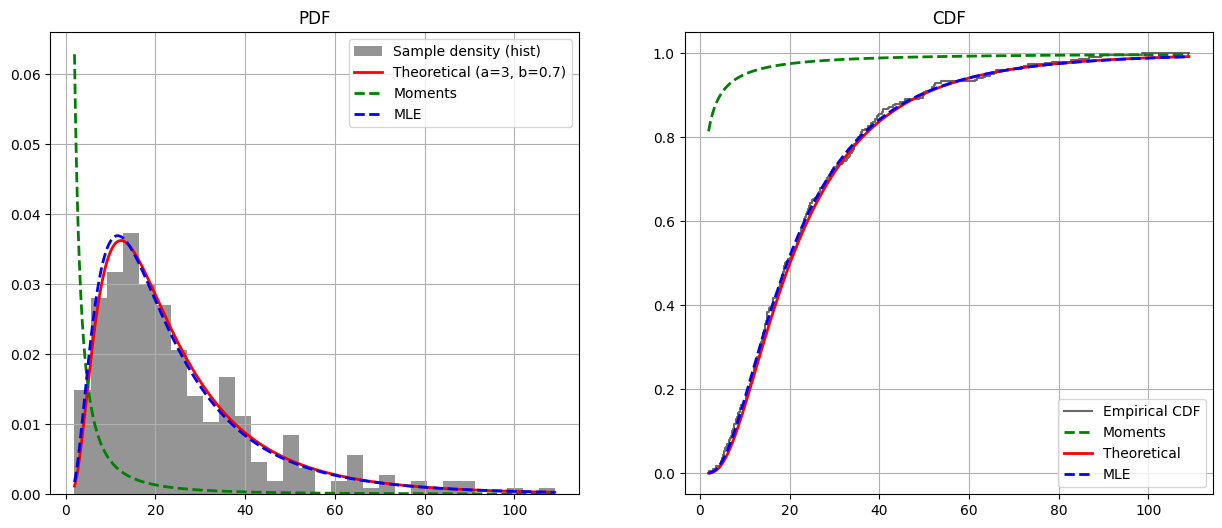

In [75]:
x = np.linspace(test_sample.min(), test_sample.max(), 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.hist(
    test_sample, bins=30, density=True, alpha=0.7, color="dimgrey", label="Sample density (hist)"
)
# Theoretical PDF
ax1.plot(
    x,
    population_lognorm.pdf(x),
    "r-",
    lw=2,
    label="Theoretical (a=3, b=0.7)",
)

# Mom PDF
ax1.plot(
    x,
    stats.lognorm.pdf(x, s=b_mom_alp1mu2, scale=np.exp(a_mom_alp1mu2)),
    "g--",
    lw=2,
    label="Moments",
)

# MLE PDF
ax1.plot(
    x,
    stats.lognorm.pdf(x, s=b_mle, scale=np.exp(a_mle)),
    "b--",
    lw=2,
    label="MLE",
)
ax1.set_title("PDF")
ax1.legend()
ax1.grid(True)

# Empirical CDF
x_emp = np.sort(test_sample)
y_emp = np.arange(1, len(x_emp) + 1) / len(x_emp)
ax2.step(x_emp, y_emp, "dimgray", alpha=1, label="Empirical CDF")

# Mom CDF
ax2.plot(
    x,
    stats.lognorm.cdf(x, s=b_mom_alp1mu2, scale=np.exp(a_mom_alp1mu2)),
    "g--",
    lw=2,
    label="Moments",
)

# Theoretical CDF
ax2.plot(
    x, stats.lognorm.cdf(x, s=b_sigma, scale=np.exp(a_mu)), "r-", lw=2, label="Theoretical"
)

# MLE CDF
ax2.plot(
    x,
    stats.lognorm.cdf(x, s=b_mle, scale=np.exp(a_mle)),
    "b--",
    lw=2,
    label="MLE",
)

ax2.set_title("CDF")
ax2.legend()
ax2.grid(True)

plt.show()